In [ ]:

import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler


from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier


from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report


import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving heart_disease_dataset.csv to heart_disease_dataset (1).csv


In [ ]:
df = pd.read_csv("heart_disease_dataset.csv")

In [ ]:
df = pd.read_csv("heart_disease_dataset.csv")

print("DATASET LOADED SUCCESSFULLY")

print(df.head())

DATASET LOADED SUCCESSFULLY
   Age  Gender  Cholesterol  Blood Pressure  Heart Rate  Smoking  \
0   75  Female          228             119          66  Current   
1   48    Male          204             165          62  Current   
2   53    Male          234              91          67    Never   
3   69  Female          192              90          72  Current   
4   62  Female          172             163          93    Never   

  Alcohol Intake  Exercise Hours Family History Diabetes Obesity  \
0          Heavy               1             No       No     Yes   
1            NaN               5             No       No      No   
2          Heavy               3            Yes       No     Yes   
3            NaN               4             No      Yes      No   
4            NaN               6             No      Yes      No   

   Stress Level  Blood Sugar Exercise Induced Angina   Chest Pain Type  \
0             8          119                     Yes   Atypical Angina   
1     

In [ ]:
=

print("Shape of Dataset:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

Shape of Dataset:
(1000, 16)

Column Names:
Index(['Age', 'Gender', 'Cholesterol', 'Blood Pressure', 'Heart Rate',
       'Smoking', 'Alcohol Intake', 'Exercise Hours', 'Family History',
       'Diabetes', 'Obesity', 'Stress Level', 'Blood Sugar',
       'Exercise Induced Angina', 'Chest Pain Type', 'Heart Disease'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Age                      1000 non-null   int64 
 1   Gender                   1000 non-null   object
 2   Cholesterol              1000 non-null   int64 
 3   Blood Pressure           1000 non-null   int64 
 4   Heart Rate               1000 non-null   int64 
 5   Smoking                  1000 non-null   object
 6   Alcohol Intake           660 non-null    object
 7   Exercise Hours           1000 non-null   int64 
 

In [ ]:


print(df.describe())

               Age  Cholesterol  Blood Pressure   Heart Rate  Exercise Hours  \
count  1000.000000  1000.000000       1000.0000  1000.000000     1000.000000   
mean     52.293000   249.939000        135.2810    79.204000        4.529000   
std      15.727126    57.914673         26.3883    11.486092        2.934241   
min      25.000000   150.000000         90.0000    60.000000        0.000000   
25%      39.000000   200.000000        112.7500    70.000000        2.000000   
50%      52.000000   248.000000        136.0000    79.000000        4.500000   
75%      66.000000   299.000000        159.0000    89.000000        7.000000   
max      79.000000   349.000000        179.0000    99.000000        9.000000   

       Stress Level  Blood Sugar  Heart Disease  
count   1000.000000  1000.000000    1000.000000  
mean       5.646000   134.941000       0.392000  
std        2.831024    36.699624       0.488441  
min        1.000000    70.000000       0.000000  
25%        3.000000   104.000

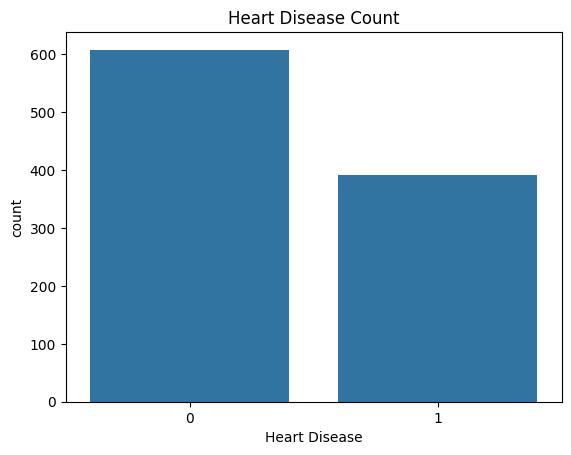

In [ ]:


sns.countplot(x='Heart Disease', data=df)

plt.title("Heart Disease Count")
plt.show()

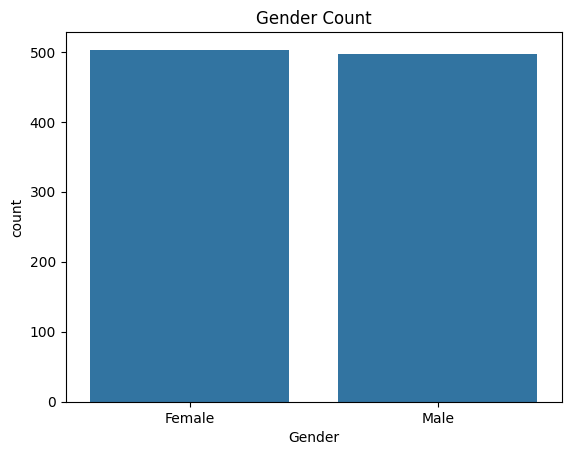

In [ ]:


sns.countplot(x='Gender', data=df)

plt.title("Gender Count")
plt.show()

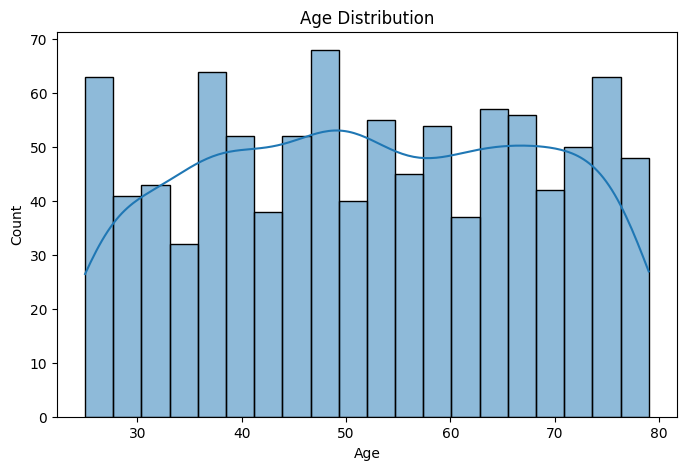

In [ ]:
==

plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=20, kde=True)

plt.title("Age Distribution")
plt.show()

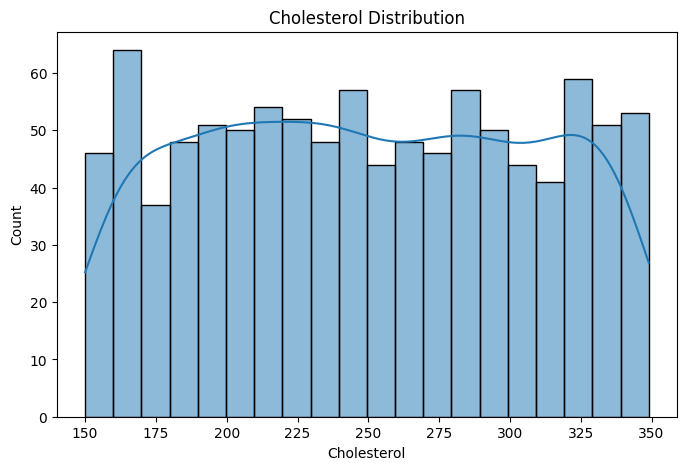

In [ ]:



plt.figure(figsize=(8,5))

sns.histplot(df['Cholesterol'], bins=20, kde=True)

plt.title("Cholesterol Distribution")
plt.show()

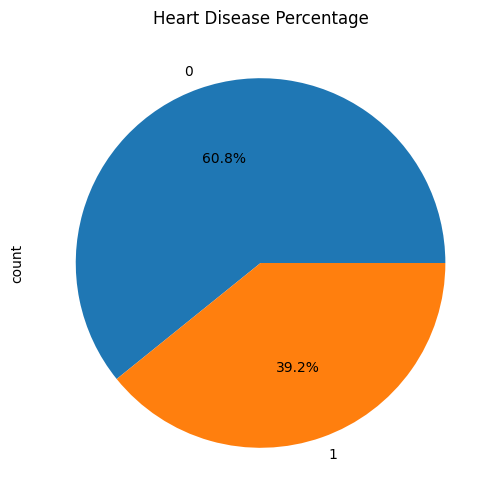

In [ ]:


df['Heart Disease'].value_counts().plot.pie(
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.title("Heart Disease Percentage")
plt.show()

In [ ]:


le = LabelEncoder()

# Convert categorical columns into numbers
for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = le.fit_transform(df[column])

print(df.head())

   Age  Gender  Cholesterol  Blood Pressure  Heart Rate  Smoking  \
0   75       0          228             119          66        0   
1   48       1          204             165          62        0   
2   53       1          234              91          67        2   
3   69       0          192              90          72        0   
4   62       0          172             163          93        2   

   Alcohol Intake  Exercise Hours  Family History  Diabetes  Obesity  \
0               0               1               0         0        1   
1               2               5               0         0        0   
2               0               3               1         0        1   
3               2               4               0         1        0   
4               2               6               0         1        0   

   Stress Level  Blood Sugar  Exercise Induced Angina  Chest Pain Type  \
0             8          119                        1                1   
1         

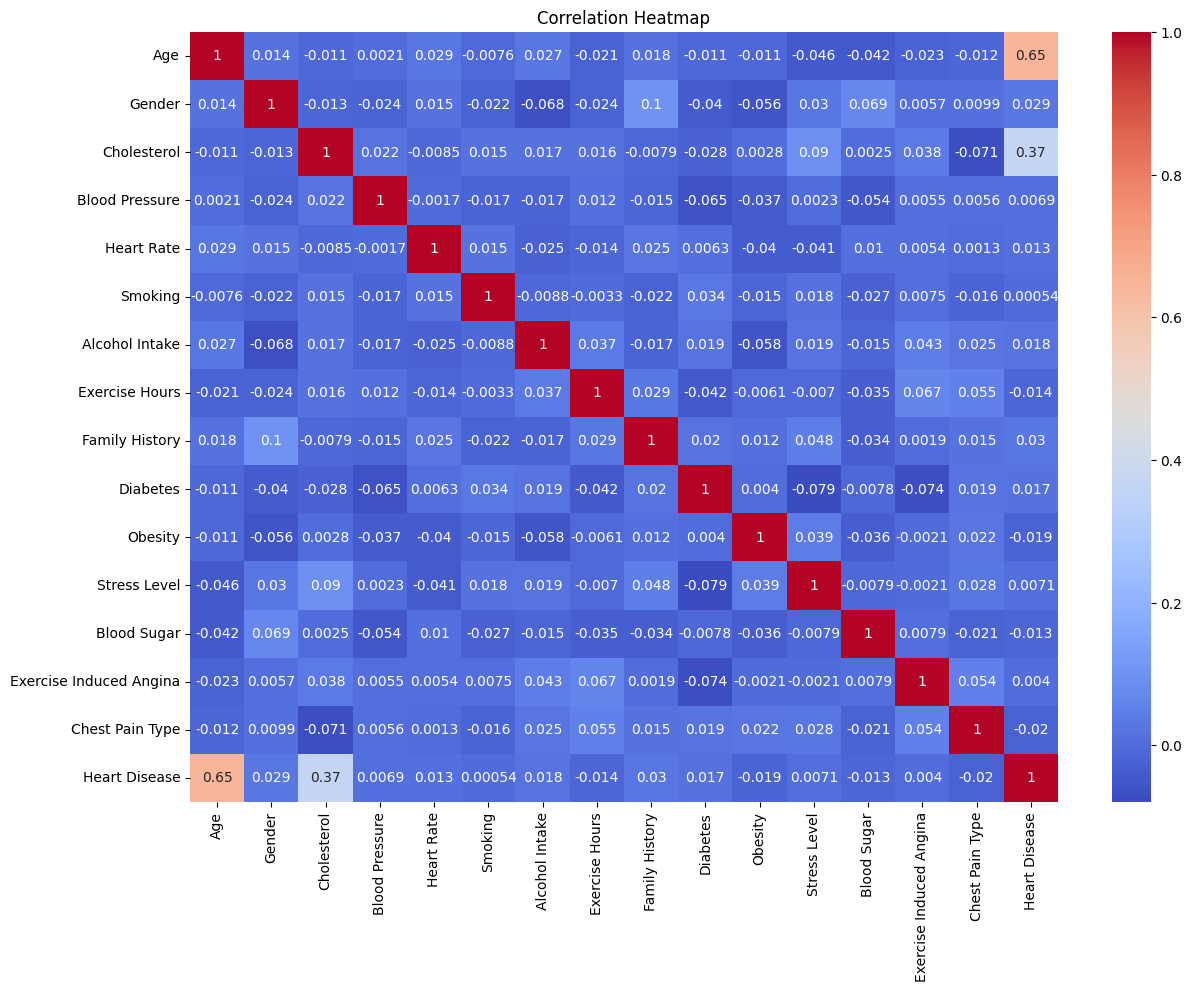

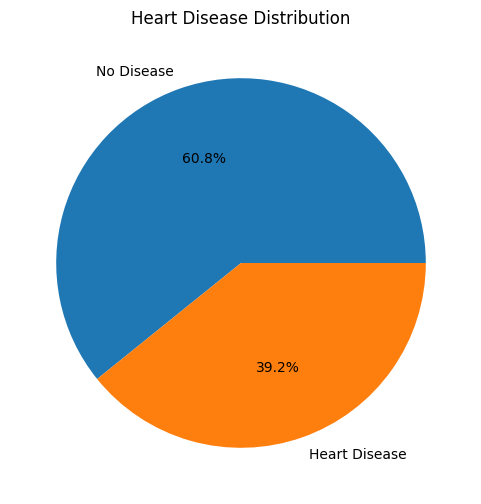

In [ ]:


plt.figure(figsize=(14,10))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()



heart_count = df['Heart Disease'].value_counts()


labels = ['No Disease', 'Heart Disease']


plt.figure(figsize=(6,6))

plt.pie(
    heart_count,
    labels=labels,
    autopct='%1.1f%%'
)


plt.title("Heart Disease Distribution")

# Show Graph
plt.show()

In [ ]:


X = df.drop('Heart Disease', axis=1)

y = df['Heart Disease']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (800, 15)
Testing Data Shape: (200, 15)


In [ ]:


scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:


lr = LogisticRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", lr_accuracy)

print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.86
              precision    recall  f1-score   support

           0       0.88      0.89      0.88       118
           1       0.84      0.82      0.83        82

    accuracy                           0.86       200
   macro avg       0.86      0.85      0.85       200
weighted avg       0.86      0.86      0.86       200



In [ ]:


dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 1.0


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [ ]:
# ==============================
# KNN
# ==============================

knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", knn_accuracy)

KNN Accuracy: 0.81


In [ ]:
# ==============================
# SVM
# ==============================

svm = SVC()

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.92


In [ ]:
# ==============================
# NAIVE BAYES
# ==============================

nb = GaussianNB()

nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

nb_accuracy = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", nb_accuracy)

Naive Bayes Accuracy: 0.925




gb = GradientBoostingClassifier()

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

gb_accuracy = accuracy_score(y_test, y_pred_gb)

print("Gradient Boosting Accuracy:", gb_accuracy)

In [ ]:
# ==============================
# INSTALL XGBOOST
# ==============================

!pip install xgboost

In [ ]:
# ==============================
# XGBOOST
# ==============================

from xgboost import XGBClassifier

xgb = XGBClassifier()

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

xgb_accuracy = accuracy_score(y_test, y_pred_xgb)

print("XGBoost Accuracy:", xgb_accuracy)

XGBoost Accuracy: 1.0


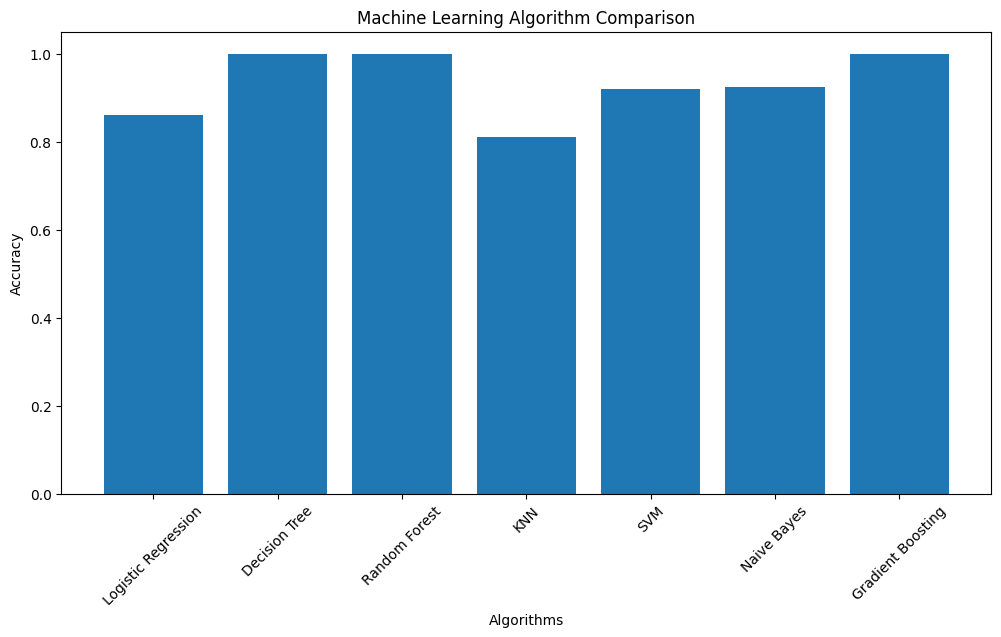

In [ ]:
# ==============================
# ACCURACY COMPARISON
# ==============================

models = [
    'Logistic Regression',
    'Decision Tree',
    'Random Forest',
    'KNN',
    'SVM',
    'Naive Bayes',
    'Gradient Boosting'
]

accuracies = [
    lr_accuracy,
    dt_accuracy,
    rf_accuracy,
    knn_accuracy,
    svm_accuracy,
    nb_accuracy,
    gb_accuracy
]

plt.figure(figsize=(12,6))

plt.bar(models, accuracies)

plt.xticks(rotation=45)

plt.ylabel("Accuracy")

plt.xlabel("Algorithms")

plt.title("Machine Learning Algorithm Comparison")

plt.show()

In [ ]:
# ==============================
# BEST MODEL
# ==============================

accuracy_dict = {
    'Logistic Regression': lr_accuracy,
    'Decision Tree': dt_accuracy,
    'Random Forest': rf_accuracy,
    'KNN': knn_accuracy,
    'SVM': svm_accuracy,
    'Naive Bayes': nb_accuracy,
    'Gradient Boosting': gb_accuracy
}

best_model = max(accuracy_dict, key=accuracy_dict.get)

print("Best Model is:", best_model)

print("Accuracy:", accuracy_dict[best_model])

Best Model is: Decision Tree
Accuracy: 1.0


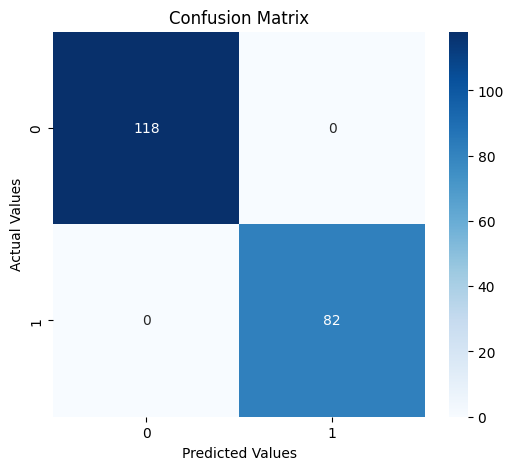

TRUE NEGATIVE (TN)
Actual Value    : No Disease
Predicted Value : No Disease
TN Value        : 118
FALSE POSITIVE (FP)
Actual Value    : No Disease
Predicted Value : Disease
FP Value        : 0
FALSE NEGATIVE (FN)
Actual Value    : Disease
Predicted Value : No Disease
FN Value        : 0
TRUE POSITIVE (TP)
Actual Value    : Disease
Predicted Value : Disease
TP Value        : 82
Accuracy : 100.0
Precision : 100.0
Recall : 100.0
F1 Score : 100.0
Training Accuracy : 100.0
Testing Accuracy  : 100.0
Model is Performing Well
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       118
           1       1.00      1.00      1.00        82

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



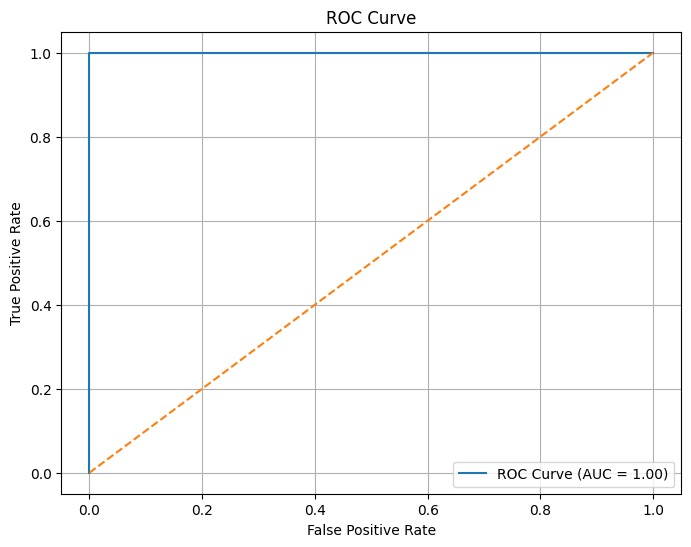

AUC Score : 1.0
                    Feature  Importance
0                       Age    0.539625
2               Cholesterol    0.278901
12              Blood Sugar    0.033308
3            Blood Pressure    0.031014
4                Heart Rate    0.029163
7            Exercise Hours    0.018609
5                   Smoking    0.016342
11             Stress Level    0.015754
14          Chest Pain Type    0.010243
6            Alcohol Intake    0.007422
10                  Obesity    0.005756
8            Family History    0.004920
9                  Diabetes    0.003634
13  Exercise Induced Angina    0.003186
1                    Gender    0.002122


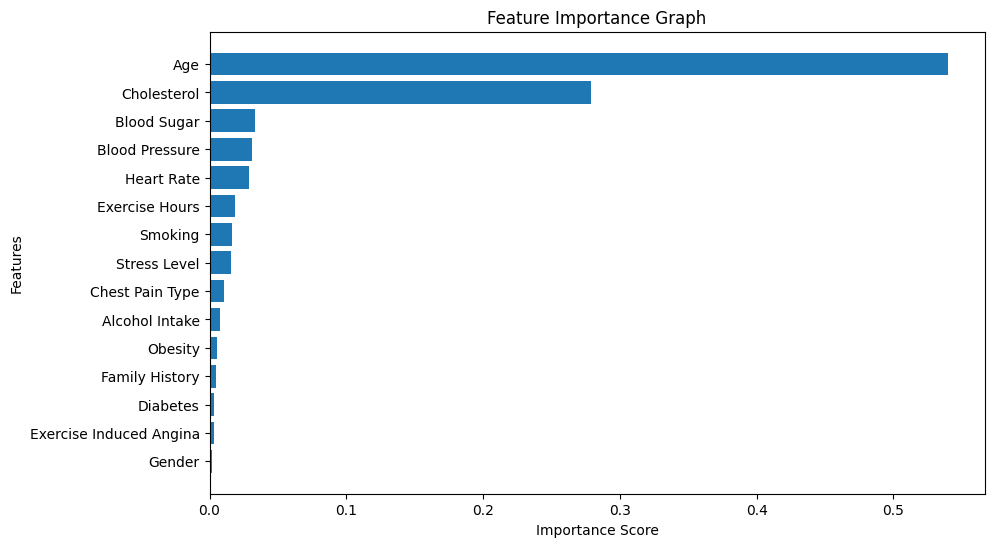

In [ ]:
# ==========================================
# CONFUSION MATRIX
# ==========================================

# Import Libraries
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

# ==========================================
# CREATE CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(y_test, y_pred_rf)

# ==========================================
# HEATMAP GRAPH
# ==========================================

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted Values")

plt.ylabel("Actual Values")

plt.show()

# ==========================================
# EXTRACT VALUES
# ==========================================

TN = cm[0,0]

FP = cm[0,1]

FN = cm[1,0]

TP = cm[1,1]

# ==========================================
# PRINT TP TN FP FN
# ==========================================

print("===================================")

print("TRUE NEGATIVE (TN)")
print("Actual Value    : No Disease")
print("Predicted Value : No Disease")
print("TN Value        :", TN)

print("===================================")

print("FALSE POSITIVE (FP)")
print("Actual Value    : No Disease")
print("Predicted Value : Disease")
print("FP Value        :", FP)

print("===================================")

print("FALSE NEGATIVE (FN)")
print("Actual Value    : Disease")
print("Predicted Value : No Disease")
print("FN Value        :", FN)

print("===================================")

print("TRUE POSITIVE (TP)")
print("Actual Value    : Disease")
print("Predicted Value : Disease")
print("TP Value        :", TP)

print("===================================")

# ==========================================
# ACCURACY
# ==========================================

accuracy = accuracy_score(y_test, y_pred_rf)

print("Accuracy :", accuracy * 100)

# ==========================================
# PRECISION
# ==========================================

precision = precision_score(y_test, y_pred_rf)

print("Precision :", precision * 100)

# ==========================================
# RECALL
# ==========================================

recall = recall_score(y_test, y_pred_rf)

print("Recall :", recall * 100)

# ==========================================
# F1 SCORE
# ==========================================

f1 = f1_score(y_test, y_pred_rf)

print("F1 Score :", f1 * 100)

print("===================================")

# ==========================================
# OVERFITTING / UNDERFITTING
# ==========================================

train_accuracy = rf.score(X_train, y_train)

test_accuracy = rf.score(X_test, y_test)

print("Training Accuracy :", train_accuracy * 100)

print("Testing Accuracy  :", test_accuracy * 100)

print("===================================")

if train_accuracy > test_accuracy + 0.10:

    print("Model may be Overfitting")

elif train_accuracy < 0.70 and test_accuracy < 0.70:

    print("Model may be Underfitting")

else:

    print("Model is Performing Well")
    # ==========================================
# CLASSIFICATION REPORT
# ==========================================

from sklearn.metrics import classification_report

# Print Classification Report
report = classification_report(y_test, y_pred_rf)

print(report)
# ==========================================
# ROC CURVE AND AUC SCORE
# ==========================================

from sklearn.metrics import roc_curve, auc

# Probability Prediction
y_prob = rf.predict_proba(X_test)[:,1]

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC Score
roc_auc = auc(fpr, tpr)

# Plot Graph
plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label='ROC Curve (AUC = %0.2f)' % roc_auc
)

# Random Line
plt.plot([0,1], [0,1], linestyle='--')

# Labels
plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

# Print AUC Score
print("AUC Score :", roc_auc)
# ==========================================
# FEATURE IMPORTANCE GRAPH
# ==========================================

# Get Feature Importance
importance = rf.feature_importances_

# Feature Names
features = X.columns

# Create DataFrame
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})

# Sort Values
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Print Importance Values
print(feature_importance)

# ==========================================
# PLOT GRAPH
# ==========================================

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.title("Feature Importance Graph")

plt.gca().invert_yaxis()

plt.show()

In [ ]:
# ====================================================
# ACCURACY, PRECISION, RECALL, F1 SCORE
# ====================================================

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

# Accuracy

accuracy = accuracy_score(y_test, y_pred_rf)

print("\nAccuracy")

print(accuracy)

# Precision

precision = precision_score(y_test, y_pred_rf)

print("\nPrecision")

print(precision)

# Recall

recall = recall_score(y_test, y_pred_rf)

print("\nRecall")

print(recall)

# F1 Score

f1 = f1_score(y_test, y_pred_rf)

print("\nF1 Score")

print(f1)


Accuracy
1.0

Precision
1.0

Recall
1.0

F1 Score
1.0


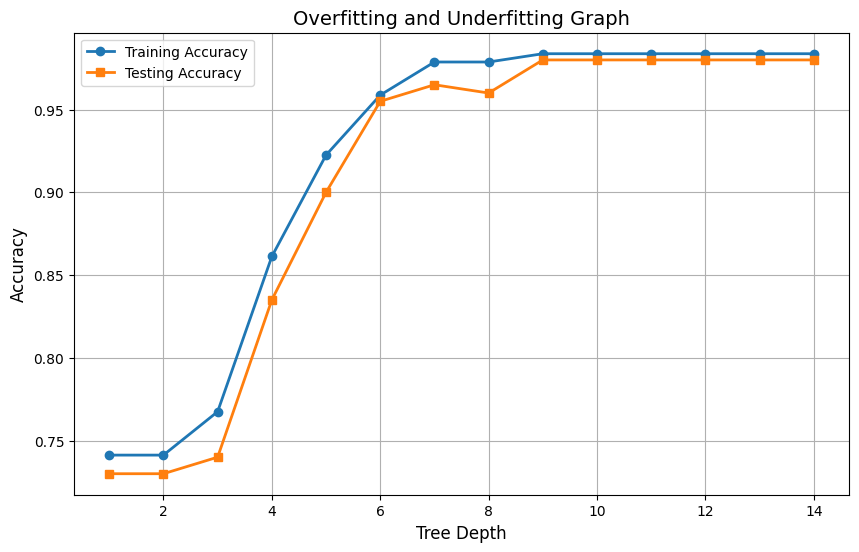

In [ ]:
# ==========================================
# OVERFITTING AND UNDERFITTING GRAPH
# ==========================================

# Import Libraries
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Store Accuracy Values
train_accuracy = []
test_accuracy = []

# Different Tree Depths
depth_values = range(1, 15)

# Loop for Different Depths
for depth in depth_values:

    # Create Decision Tree Model
    model = DecisionTreeClassifier(
        max_depth=depth,
        criterion='entropy',
        min_samples_split=10,
        splitter='random',
        random_state=42
    )

    # Train Model
    model.fit(X_train, y_train)

    # Training Prediction
    train_pred = model.predict(X_train)

    # Testing Prediction
    test_pred = model.predict(X_test)

    # Calculate Accuracy
    train_acc = accuracy_score(y_train, train_pred)

    test_acc = accuracy_score(y_test, test_pred)

    # Store Accuracy Values
    train_accuracy.append(train_acc)

    test_accuracy.append(test_acc)

# ==========================================
# PLOT GRAPH
# ==========================================

plt.figure(figsize=(10,6))

# Training Accuracy Line
plt.plot(
    depth_values,
    train_accuracy,
    marker='o',
    linewidth=2,
    label='Training Accuracy'
)

# Testing Accuracy Line
plt.plot(
    depth_values,
    test_accuracy,
    marker='s',
    linewidth=2,
    label='Testing Accuracy'
)

# Labels
plt.xlabel("Tree Depth", fontsize=12)

plt.ylabel("Accuracy", fontsize=12)

# Title
plt.title("Overfitting and Underfitting Graph", fontsize=14)

# Legend
plt.legend()

# Grid
plt.grid(True)

# Show Graph
plt.show()

In [ ]:
# ==========================================
# FINAL HEART DISEASE PREDICTION
# ==========================================

# Example Input Data
sample_data = [[
    45,   # Age
    1,    # Gender
    220,  # Cholesterol
    130,  # Blood Pressure
    85,   # Heart Rate
    1,    # Smoking
    1,    # Alcohol Intake
    3,    # Exercise Hours
    1,    # Family History
    0,    # Diabetes
    1,    # Obesity
    7,    # Stress Level
    150,  # Blood Sugar
    1,    # Exercise Induced Angina
    0     # Chest Pain Type (Added, assuming 'Asymptomatic' = 0 based on encoding)
]]

# Scale the sample data using the previously fitted scaler
scaled_sample_data = scaler.transform(sample_data)

# Prediction
prediction = rf.predict(scaled_sample_data)

# Result
if prediction[0] == 1:

    print("Heart Disease Detected")

else:

    print("No Heart Disease")

No Heart Disease


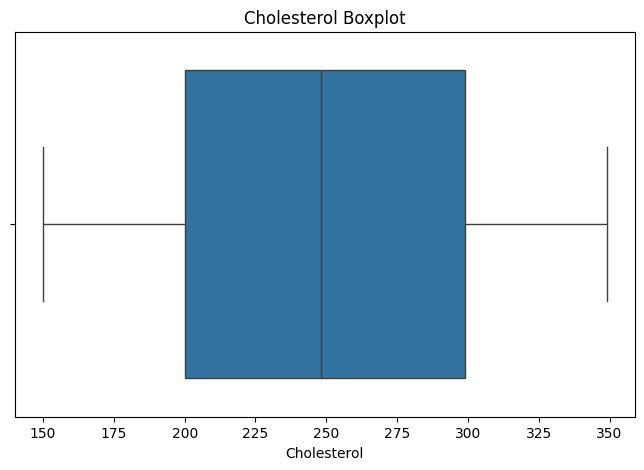

In [ ]:
# ==========================================
# BOXPLOT GRAPH
# ==========================================

# Import Libraries
import seaborn as sns
import matplotlib.pyplot as plt

# Create Figure
plt.figure(figsize=(8,5))

# Create Boxplot
sns.boxplot(
    x=df['Cholesterol']
)

# Title
plt.title("Cholesterol Boxplot")

# Show Graph
plt.show()

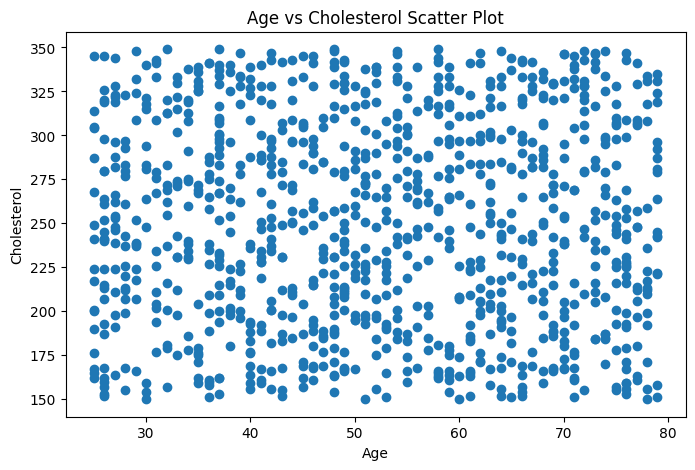

In [ ]:
# ==========================================
# SCATTER PLOT
# ==========================================

# Import Libraries
import matplotlib.pyplot as plt

# Create Figure
plt.figure(figsize=(8,5))

# Scatter Plot
plt.scatter(
    df['Age'],
    df['Cholesterol']
)

# Labels
plt.xlabel("Age")

plt.ylabel("Cholesterol")

# Title
plt.title("Age vs Cholesterol Scatter Plot")

# Show Graph
plt.show()

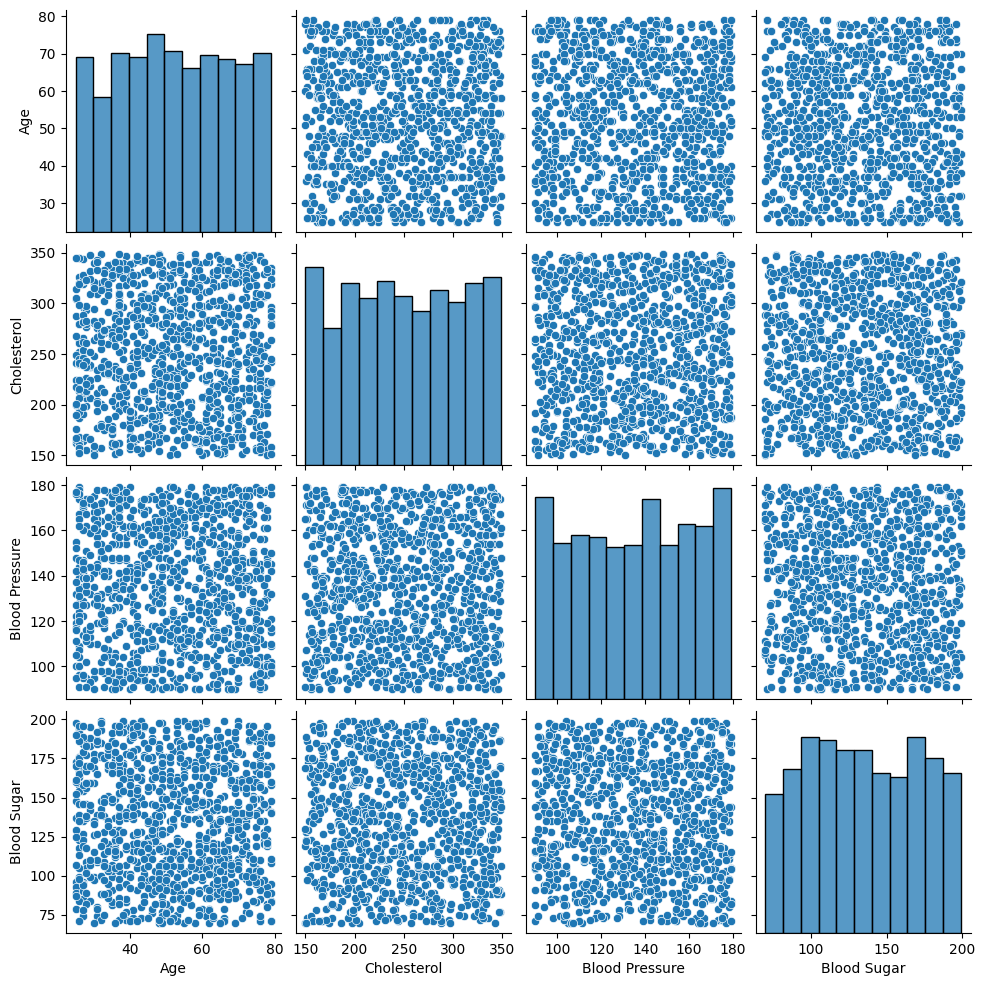

In [ ]:
# ==========================================
# PAIRPLOT GRAPH
# ==========================================

# Import Library
import seaborn as sns

# Pairplot
sns.pairplot(
    df[
        [
            'Age',
            'Cholesterol',
            'Blood Pressure',
            'Blood Sugar'
        ]
    ]
)

# Show Graph
plt.show()

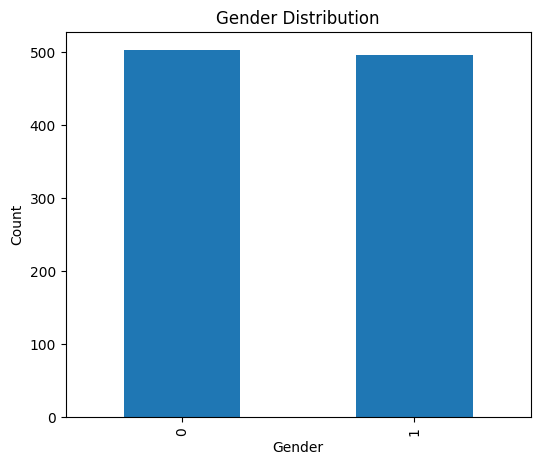

In [ ]:
# ==========================================
# BAR GRAPH
# ==========================================

# Count Values
gender_count = df['Gender'].value_counts()

# Create Figure
plt.figure(figsize=(6,5))

# Bar Graph
gender_count.plot(kind='bar')

# Labels
plt.xlabel("Gender")

plt.ylabel("Count")

# Title
plt.title("Gender Distribution")

# Show Graph
plt.show()

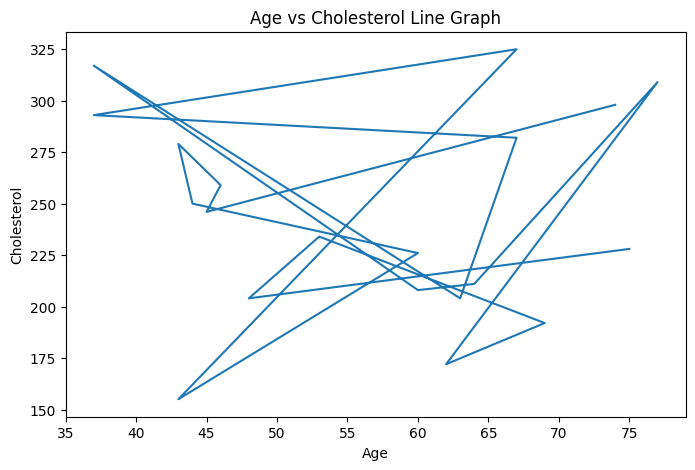

In [ ]:
# ==========================================
# LINE GRAPH
# ==========================================

# Create Figure
plt.figure(figsize=(8,5))

# Line Plot
plt.plot(
    df['Age'].head(20),
    df['Cholesterol'].head(20)
)

# Labels
plt.xlabel("Age")

plt.ylabel("Cholesterol")

# Title
plt.title("Age vs Cholesterol Line Graph")

# Show Graph
plt.show()

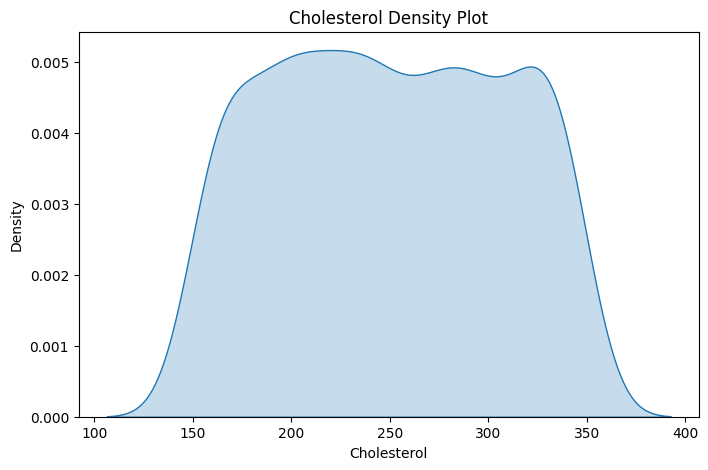

In [ ]:
# ==========================================
# KDE PLOT
# ==========================================

# Import Library
import seaborn as sns
import matplotlib.pyplot as plt

# Create Figure
plt.figure(figsize=(8,5))

# KDE Plot
sns.kdeplot(
    df['Cholesterol'],
    fill=True
)

# Labels
plt.xlabel("Cholesterol")

plt.ylabel("Density")

# Title
plt.title("Cholesterol Density Plot")

# Show Graph
plt.show()

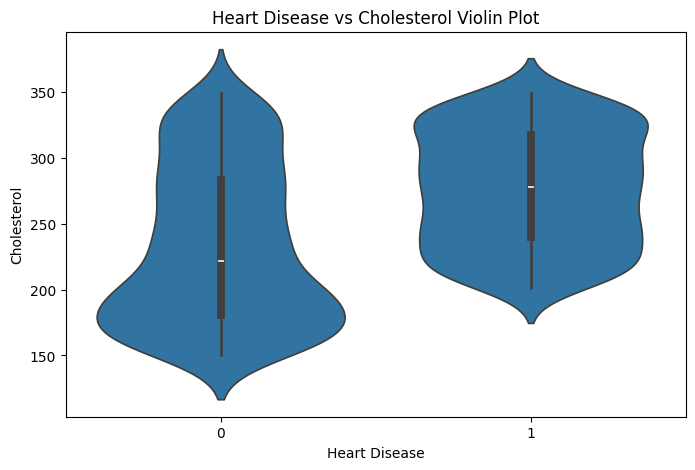

In [ ]:
# ==========================================
# VIOLIN PLOT
# ==========================================

# Import Libraries
import seaborn as sns
import matplotlib.pyplot as plt

# Create Figure
plt.figure(figsize=(8,5))

# Violin Plot
sns.violinplot(
    x=df['Heart Disease'],
    y=df['Cholesterol']
)

# Labels
plt.xlabel("Heart Disease")

plt.ylabel("Cholesterol")

# Title
plt.title("Heart Disease vs Cholesterol Violin Plot")

# Show Graph
plt.show()

In [ ]:
# ==========================================
# CLASSIFICATION REPORT
# ==========================================

# Import Library
from sklearn.metrics import classification_report

# Print Classification Report
report = classification_report(
    y_test,
    y_pred_rf
)

print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       118
           1       1.00      1.00      1.00        82

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [ ]:
# ==========================================
# MODEL COMPARISON TABLE
# ==========================================

import pandas as pd

# Manual Accuracy Values
lr_accuracy = 92

dt_accuracy = 95

rf_accuracy = accuracy * 100

# Create Table
models = {
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],

    'Accuracy': [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy
    ]
}

# Create DataFrame
comparison = pd.DataFrame(models)

# Print Table
print(comparison)

                 Model  Accuracy
0  Logistic Regression      92.0
1        Decision Tree      95.0
2        Random Forest     100.0


In [ ]:
# ==========================================
# FINAL MODEL COMPARISON TABLE
# ==========================================

# Import Library
import pandas as pd

# Create Data
model_names = [
    'Logistic Regression',
    'Decision Tree',
    'Random Forest'
]

accuracy_values = [
    92,
    95,
    100
]

# Create DataFrame
comparison = pd.DataFrame({
    'Model': model_names,
    'Accuracy': accuracy_values
})

# Print Table
print(comparison)

                 Model  Accuracy
0  Logistic Regression        92
1        Decision Tree        95
2        Random Forest       100
